In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
mouse = 25
day = 24

# good examples include 
#mice = [25, 25, 26, 27, 29, 28]
#days = [25, 24, 18, 26, 23, 25]

25 24
there are 44 non_grid and non_spatial_cells
there are 23 grid_cells
there are 40 non grid spatial cells
there are 4 non spatial cells
there are 2 speed cells
there are 69 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 26.979441530612775
Not merging labels 0 and 2 with distance 16.455743681011175
Not merging labels 1 and 2 with distance 10.686836455593717
Found 4 modules with HDBSCAN for mouse 25 day 24
for each module , the number of points is: [ 1  5  4 13]


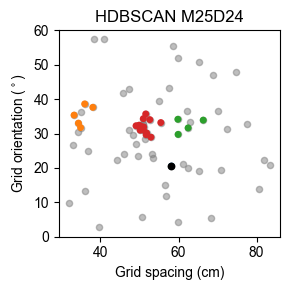

for module 0, there are 5 cells with average spacing 35.305404003465775
for module 1, there are 4 cells with average spacing 62.127313214275674
for module 2, there are 13 cells with average spacing 51.44469907502155
module 0 contains cells from ['VISpl5']
module 2 contains cells from ['ENTm2' 'VISpl5']
module 1 contains cells from ['ENTm1' 'ENTm2']
25 24
for module 0, there are 5 cells
for module 2, there are 13 cells
for module 1, there are 4 cells


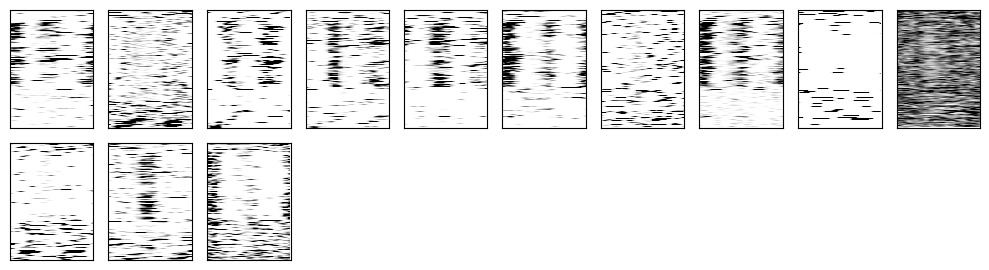

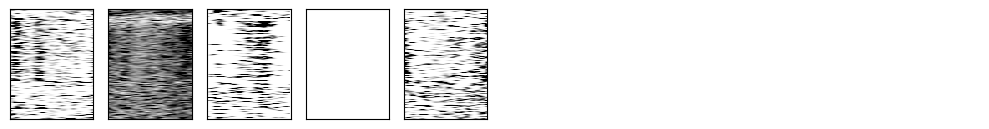

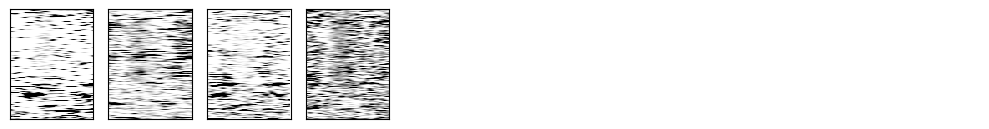

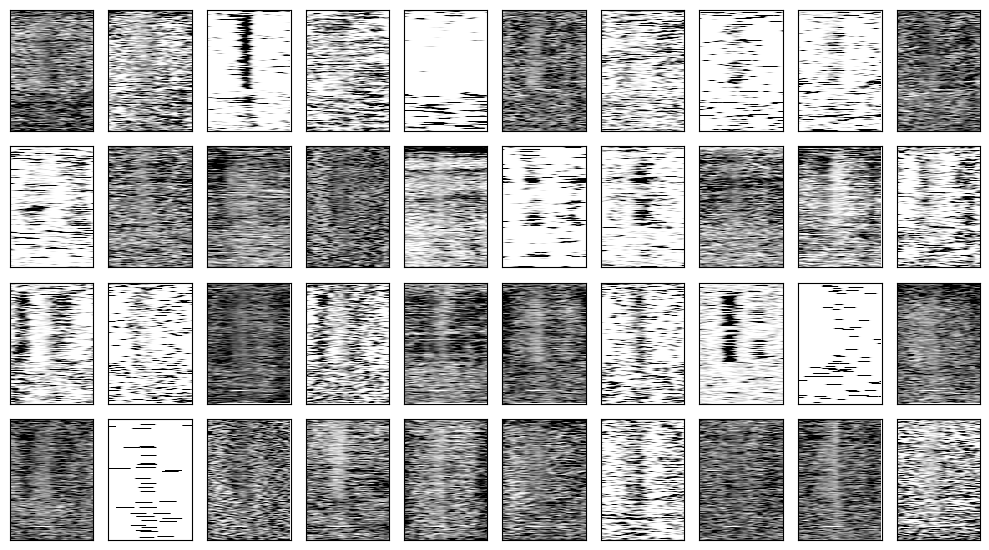

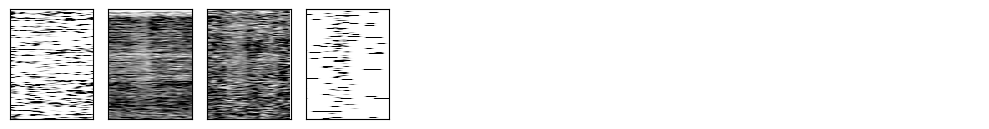

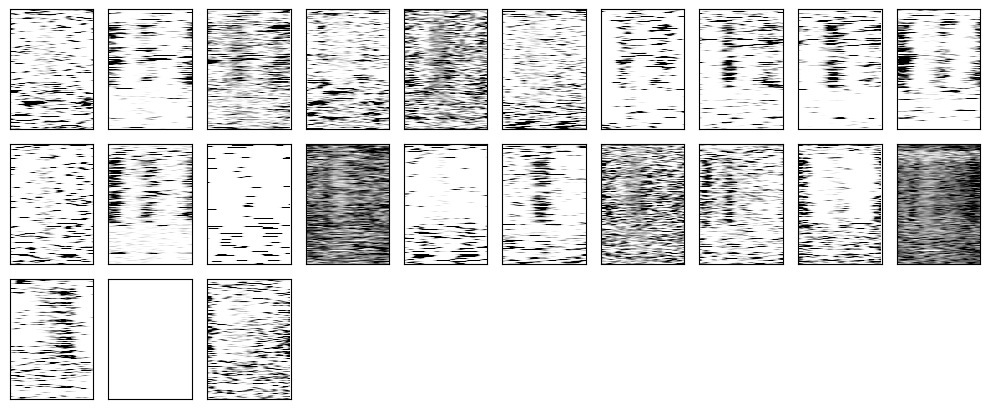

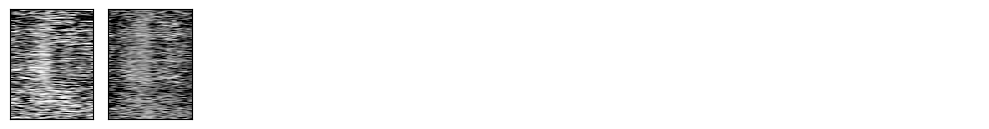

In [3]:
gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
rc, rsc, vr_ns = cell_classification_vr(mouse, day)

g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True) # create grid modules using HDBSCAN    

plot_grid_modules_rate_maps(gcs, g_m_ids, g_m_cluster_ids, mouse, day, figpath=fig_path)

# we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
# as defined by activity in the open field
g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
cluster_ids_by_group = []
cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]

for m, cluster_ids in enumerate(cluster_ids_by_group):
    plot_vr_rate_maps(mouse, day, cluster_ids, label=f'{m}', figpath=fig_path)

tcs,tcs_time,_,_,_,_ = compute_vr_tcs(mouse, day)


Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
[12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 28 28 12 12 12 12 12
 12 12 12 12 12 12 12 12 12 12 12 12 12 28 28 28 28 28 28 28 28 28 28 28
 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12
 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 19 19 19 12 12 12 12 12
 12 12 28 28 28 28 29 28 28]


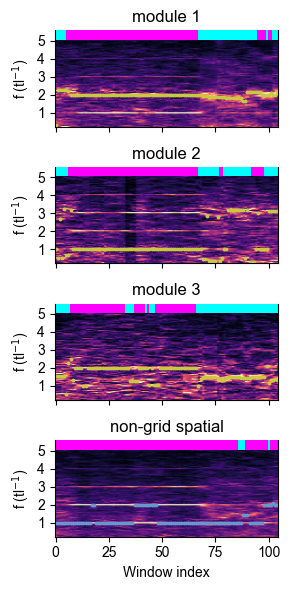

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

peak_indices = [12, 28, 44, 60, 76]

fig, ax = plt.subplots(
    nrows=len(g_m_cluster_ids)+1,
    ncols=1,
    figsize=(3, 6),
    squeeze=False,
    sharex='col'
)

for m in range(len(g_m_cluster_ids)):
    cluster_ids = g_m_cluster_ids[m]
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    S = spectrograms.mean(0)
    # Spectrogram
    ax[m,0].set_title(f'module {m+1}')
    ax[m,0].imshow(S, origin='lower', aspect='auto', vmax=0.25, cmap='magma')
    max_peaks = np.argmax(S, axis=0)
    ax[m,0].scatter(np.arange(S.shape[1]), max_peaks, color='#CAC841',s=3)
    ax[m,0].set_yticks(peak_indices, [1, 2, 3, 4, 5])
    ax[m,0].set_ylabel(r'f (tl$^{-1}$)')
    ax[m,0].spines['top'].set_visible(False)
    
    # Cluster labels: 1 if max at peak_indices_gm, else 0
    labels = np.isin(max_peaks, peak_indices).astype(int)
    ax[m,0].scatter(
        np.arange(S.shape[1]),
        np.full(S.shape[1], 81),  # y just above the top
        c=labels,
        cmap='cool',
        marker='s',
        s=50,
        edgecolor='none',
        clip_on=True
    )

# Non-grid spatial row
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3] 
S = spectrograms.mean(0)
ax[-1,0].set_title(f'non-grid spatial')
ax[-1,0].imshow(S, origin='lower', aspect='auto', vmax=0.25, cmap='magma')
max_peaks = np.argmax(S, axis=0)
ax[-1,0].scatter(np.arange(S.shape[1]), max_peaks, color='#6897CD',s=3)
ax[-1,0].set_yticks(peak_indices, [1, 2, 3, 4, 5])
ax[-1,0].set_ylabel(r'f (tl$^{-1}$)')
ax[-1,0].set_xlabel('Window index')
ax[-1,0].spines['top'].set_visible(False)
labels = np.isin(max_peaks, peak_indices).astype(int)
print(max_peaks)
ax[-1,0].scatter(
    np.arange(S.shape[1]),
    np.full(S.shape[1], 81),  # y just above the top
    c=labels,
    cmap='cool',
    marker='s',
    s=50,
    edgecolor='none',
    clip_on=True
)
plt.tight_layout()
plt.show()

20 14
there are 169 non_grid and non_spatial_cells
there are 0 grid_cells
there are 93 non grid spatial cells
there are 76 non spatial cells
there are 35 speed cells
there are 204 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (77, 105)
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12
 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12
 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12
 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12
 12 12 12 12 12 12 12 12 12]


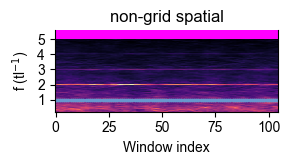

In [5]:
mouse_days = {20: [14],
              }

for mouse, days in mouse_days.items():
    for day in days:
        tcs, tcs_time, _, _, _, _ = compute_vr_tcs(mouse, day)

        gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95)
        # Grid cells
        g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                        figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True)
        
        fig, ax = plt.subplots(
            nrows=len(g_m_cluster_ids)+1,
            ncols=1,
            figsize=(3, (len(g_m_cluster_ids)+1)*1.75),
            squeeze=False,
            sharex='col'
        )
        
        for m, cluster_ids in enumerate(g_m_cluster_ids):
            tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
            results = spectral_analysis(tcs_to_use, tl, bs=bs)
            spectrograms = results[3] 
            S = spectrograms.mean(0)
            # Spectrogram
            ax[m,0].set_title(f'module {m+1}')
            ax[m,0].imshow(S, origin='lower', aspect='auto', vmax=0.25, cmap='magma')
            max_peaks = np.argmax(S, axis=0)
            ax[m,0].scatter(np.arange(S.shape[1]), max_peaks, color='#CAC841',s=3)
            ax[m,0].set_yticks(peak_indices, [1, 2, 3, 4, 5])
            ax[m,0].set_ylabel(r'f (tl$^{-1}$)')
            ax[m,0].spines['top'].set_visible(False)
            
            # Cluster labels: 1 if max at peak_indices_gm, else 0
            labels = np.isin(max_peaks, peak_indices).astype(float)
            ax[m,0].scatter(
                np.arange(S.shape[1]),
                np.full(S.shape[1], 81),  # y just above the top
                c=labels,
                cmap='cool',
                marker='s',
                s=50,
                edgecolor='none',
                vmin=0, vmax=1,
                clip_on=True
            )

        # Non-grid spatial cells
        tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs}
        results = spectral_analysis(tcs_to_use, tl, bs=bs)
        spectrograms = results[3] 
        S = spectrograms.mean(0)

        print(f'shape of S: {S.shape}')
        # spectrogram
        ax[-1,0].set_title(f'non-grid spatial')
        ax[-1,0].imshow(S, origin='lower', aspect='auto', vmax=0.25, cmap='magma')
        max_peaks = np.argmax(S, axis=0)
        ax[-1,0].scatter(np.arange(S.shape[1]), max_peaks, color='#6897CD',s=3)
        ax[-1,0].set_yticks(peak_indices, [1, 2, 3, 4, 5])
        ax[-1,0].set_ylabel(r'f (tl$^{-1}$)')
        ax[-1,0].set_xlabel('Window index')
        ax[-1,0].spines['top'].set_visible(False)
        labels = np.isin(max_peaks, peak_indices).astype(int)
        print(labels)
        print(max_peaks)
        ax[-1,0].scatter(
            np.arange(S.shape[1]),
            np.full(S.shape[1], 81),  # y just above the top
            c=labels,
            cmap='cool',
            marker='s',
            s=50,
            edgecolor='none',
            vmin=0, vmax=1,
            clip_on=True
        )
        plt.tight_layout()
        plt.show()


20 14
there are 169 non_grid and non_spatial_cells
there are 0 grid_cells
there are 93 non grid spatial cells
there are 76 non spatial cells
there are 35 speed cells
there are 204 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (77, 105)


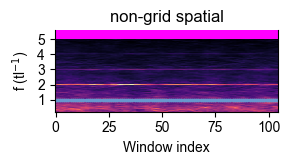

20 16
there are 178 non_grid and non_spatial_cells
there are 3 grid_cells
there are 156 non grid spatial cells
there are 22 non spatial cells
there are 38 speed cells
there are 219 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 20 day 16
for each module , the number of points is: [3]


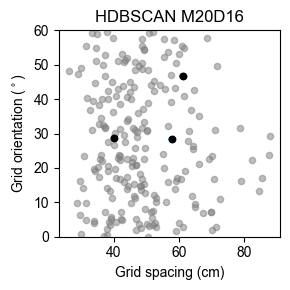

Identified 1 candidate modules
shape of S: (77, 189)


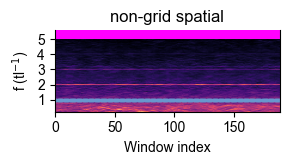

20 17
there are 112 non_grid and non_spatial_cells
there are 3 grid_cells
there are 88 non grid spatial cells
there are 24 non spatial cells
there are 17 speed cells
there are 132 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 20 day 17
for each module , the number of points is: [3]


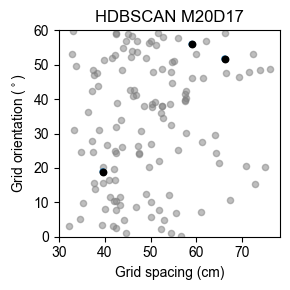

Identified 1 candidate modules
shape of S: (77, 146)


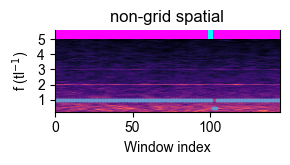

20 18
there are 139 non_grid and non_spatial_cells
there are 1 grid_cells
there are 105 non grid spatial cells
there are 34 non spatial cells
there are 11 speed cells
there are 151 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (77, 177)


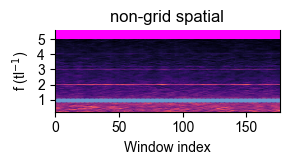

20 19
there are 111 non_grid and non_spatial_cells
there are 1 grid_cells
there are 92 non grid spatial cells
there are 19 non spatial cells
there are 5 speed cells
there are 117 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (77, 181)


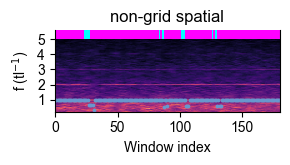

20 20
there are 89 non_grid and non_spatial_cells
there are 4 grid_cells
there are 78 non grid spatial cells
there are 11 non spatial cells
there are 10 speed cells
there are 103 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 20 day 20
for each module , the number of points is: [4]


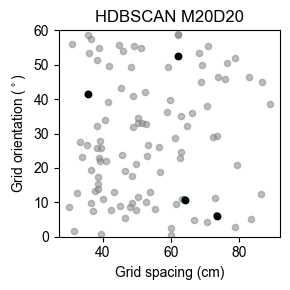

Identified 1 candidate modules
shape of S: (77, 176)


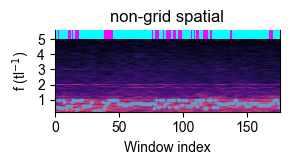

20 21
there are 111 non_grid and non_spatial_cells
there are 0 grid_cells
there are 69 non grid spatial cells
there are 42 non spatial cells
there are 5 speed cells
there are 116 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (77, 179)


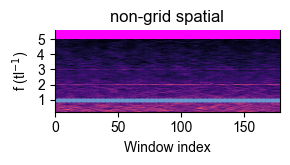

20 22
there are 73 non_grid and non_spatial_cells
there are 3 grid_cells
there are 70 non grid spatial cells
there are 3 non spatial cells
there are 4 speed cells
there are 80 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 20 day 22
for each module , the number of points is: [3]


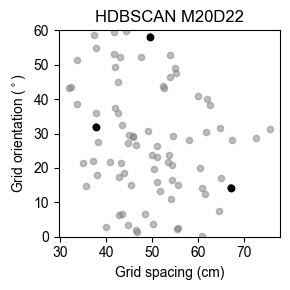

Identified 1 candidate modules
shape of S: (77, 189)


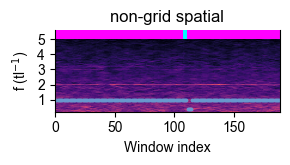

20 23
there are 66 non_grid and non_spatial_cells
there are 3 grid_cells
there are 51 non grid spatial cells
there are 15 non spatial cells
there are 16 speed cells
there are 85 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 20 day 23
for each module , the number of points is: [3]


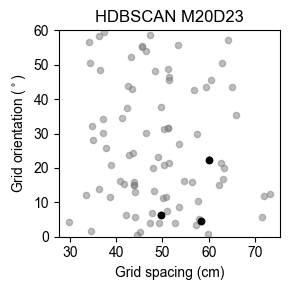

Identified 1 candidate modules
shape of S: (77, 150)


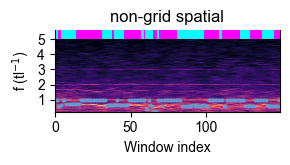

20 24
there are 77 non_grid and non_spatial_cells
there are 2 grid_cells
there are 67 non grid spatial cells
there are 10 non spatial cells
there are 1 speed cells
there are 80 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 20 day 24
for each module , the number of points is: [2]


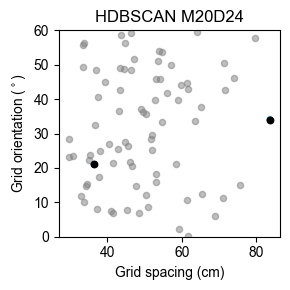

Identified 1 candidate modules
shape of S: (77, 199)


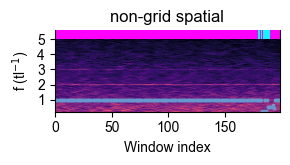

20 25
there are 24 non_grid and non_spatial_cells
there are 11 grid_cells
there are 18 non grid spatial cells
there are 6 non spatial cells
there are 1 speed cells
there are 36 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 24.799117286521856
Found 2 modules with HDBSCAN for mouse 20 day 25
for each module , the number of points is: [4 7]


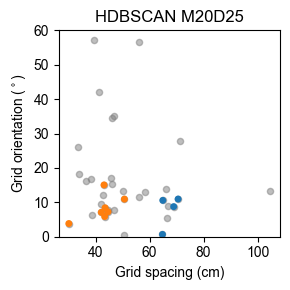

for module 0, there are 4 cells with average spacing 67.28909384604304
for module 1, there are 7 cells with average spacing 42.497564765534584
module 1 contains cells from ['ENTm3']
module 0 contains cells from ['ENTm3']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 190)


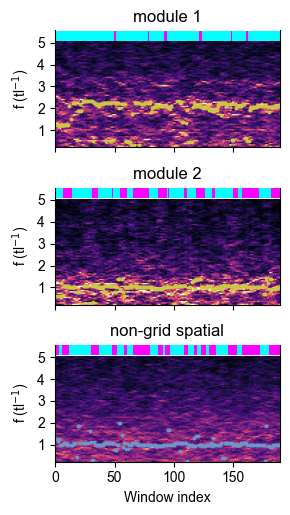

20 26
there are 133 non_grid and non_spatial_cells
there are 2 grid_cells
there are 96 non grid spatial cells
there are 37 non spatial cells
there are 19 speed cells
there are 154 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 20 day 26
for each module , the number of points is: [2]


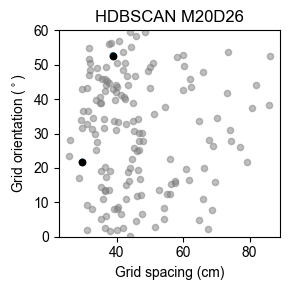

Identified 1 candidate modules
shape of S: (77, 196)


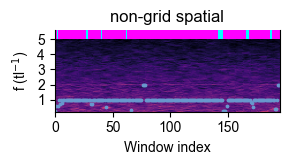

21 15
there are 181 non_grid and non_spatial_cells
there are 3 grid_cells
there are 168 non grid spatial cells
there are 13 non spatial cells
there are 58 speed cells
there are 242 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 21 day 15
for each module , the number of points is: [3]


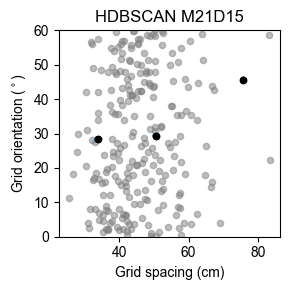

Identified 1 candidate modules
shape of S: (77, 35)


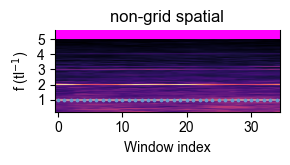

21 16
there are 194 non_grid and non_spatial_cells
there are 17 grid_cells
there are 173 non grid spatial cells
there are 21 non spatial cells
there are 29 speed cells
there are 240 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 49.147997596677136
Not merging labels 0 and 2 with distance 45.63231692326799
Not merging labels 1 and 2 with distance 39.61864589610463
Found 4 modules with HDBSCAN for mouse 21 day 16
for each module , the number of points is: [ 1  3  3 10]


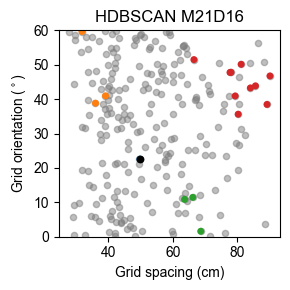

for module 0, there are 3 cells with average spacing 35.63117488281154
for module 1, there are 3 cells with average spacing 66.15685817796435
for module 2, there are 10 cells with average spacing 81.22485030108808
module 0 contains cells from ['ENTm5' 'ENTm6']
module 1 contains cells from ['ENTm2' 'ENTm6']
module 2 contains cells from ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm6']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 43)


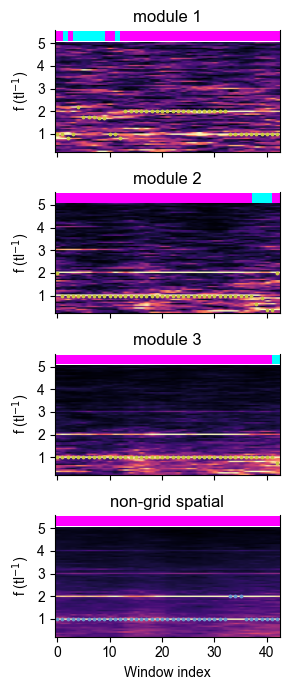

21 17
there are 215 non_grid and non_spatial_cells
there are 4 grid_cells
there are 187 non grid spatial cells
there are 28 non spatial cells
there are 45 speed cells
there are 264 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 21 day 17
for each module , the number of points is: [4]


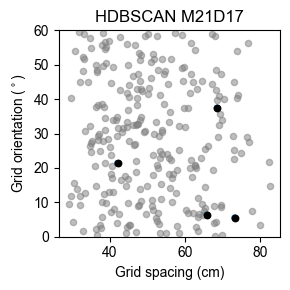

Identified 1 candidate modules
shape of S: (77, 45)


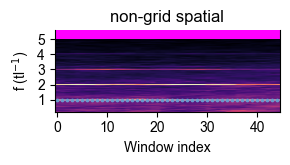

21 18
there are 149 non_grid and non_spatial_cells
there are 3 grid_cells
there are 132 non grid spatial cells
there are 17 non spatial cells
there are 34 speed cells
there are 186 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 21 day 18
for each module , the number of points is: [3]


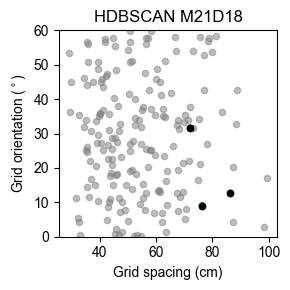

Identified 1 candidate modules
shape of S: (77, 58)


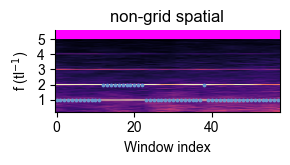

21 19
there are 371 non_grid and non_spatial_cells
there are 7 grid_cells
there are 324 non grid spatial cells
there are 47 non spatial cells
there are 35 speed cells
there are 413 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 21 day 19
for each module , the number of points is: [7]


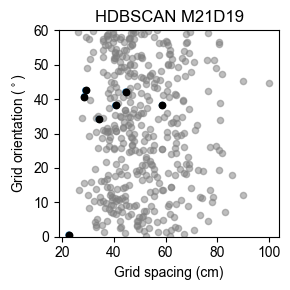

Identified 1 candidate modules
shape of S: (77, 47)


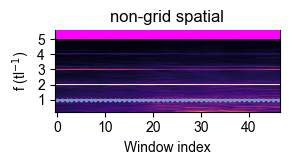

21 20
there are 290 non_grid and non_spatial_cells
there are 7 grid_cells
there are 243 non grid spatial cells
there are 47 non spatial cells
there are 29 speed cells
there are 326 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 23.301218833478337
Found 2 modules with HDBSCAN for mouse 21 day 20
for each module , the number of points is: [3 4]


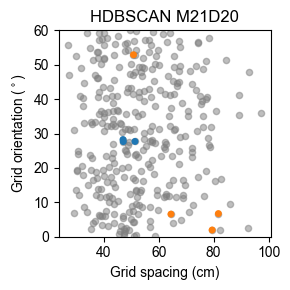

for module 0, there are 3 cells with average spacing 48.47526051620829
for module 1, there are 4 cells with average spacing 69.10889839184068
module 0 contains cells from ['ENTm6' 'VISpor6a']
module 1 contains cells from ['ENTm6']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 53)


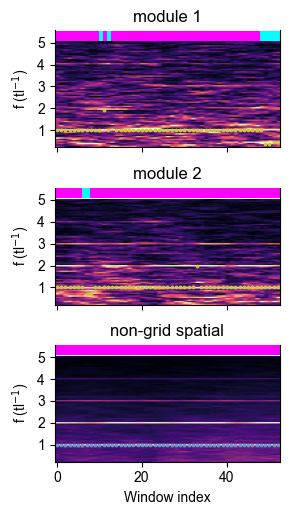

21 21
there are 246 non_grid and non_spatial_cells
there are 39 grid_cells
there are 186 non grid spatial cells
there are 60 non spatial cells
there are 30 speed cells
there are 315 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 14.463189695359064
Not merging labels 0 and 2 with distance 40.24643892881771
Not merging labels 1 and 2 with distance 26.687759183091142
Found 4 modules with HDBSCAN for mouse 21 day 21
for each module , the number of points is: [ 3  3  3 30]


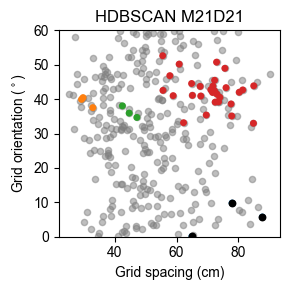

for module 0, there are 3 cells with average spacing 30.63998585780331
for module 1, there are 3 cells with average spacing 44.77260507515509
for module 2, there are 30 cells with average spacing 70.78125582859651
module 0 contains cells from ['ENTm6' 'HPF' 'VISl6a']
module 1 contains cells from ['ENTm5' 'HPF']
module 2 contains cells from ['ENTm1' 'ENTm3' 'ENTm5']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 77)


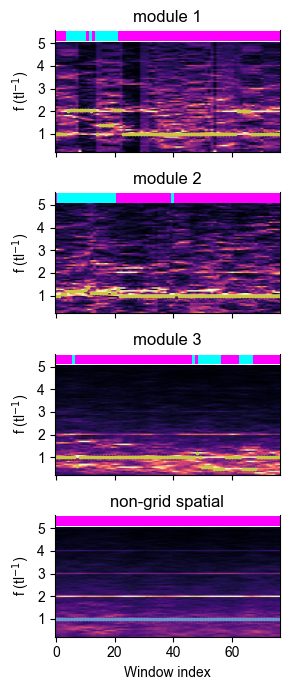

21 22
there are 127 non_grid and non_spatial_cells
there are 2 grid_cells
there are 83 non grid spatial cells
there are 44 non spatial cells
there are 12 speed cells
there are 141 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 21 day 22
for each module , the number of points is: [2]


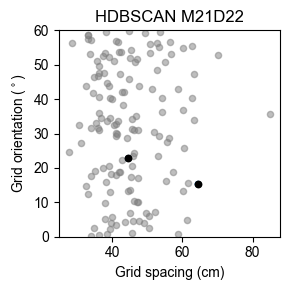

Identified 1 candidate modules
shape of S: (77, 91)


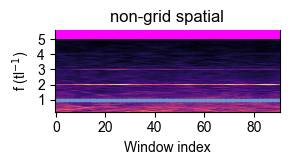

21 23
there are 321 non_grid and non_spatial_cells
there are 3 grid_cells
there are 271 non grid spatial cells
there are 50 non spatial cells
there are 20 speed cells
there are 344 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 21 day 23
for each module , the number of points is: [3]


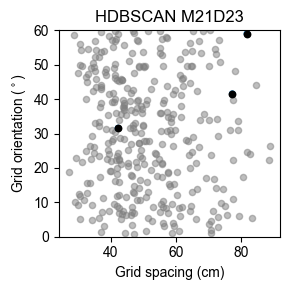

Identified 1 candidate modules
shape of S: (77, 128)


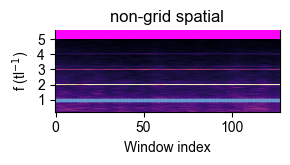

21 24
there are 206 non_grid and non_spatial_cells
there are 5 grid_cells
there are 170 non grid spatial cells
there are 36 non spatial cells
there are 7 speed cells
there are 218 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 21 day 24
for each module , the number of points is: [5]


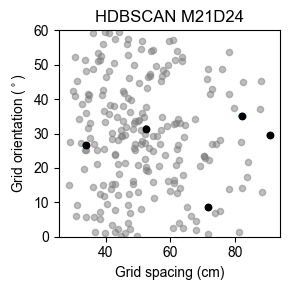

Identified 1 candidate modules
shape of S: (77, 124)


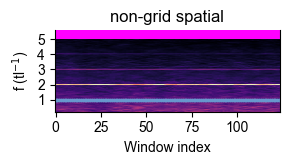

21 25
there are 158 non_grid and non_spatial_cells
there are 8 grid_cells
there are 117 non grid spatial cells
there are 41 non spatial cells
there are 10 speed cells
there are 176 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 40.15184874238774
Found 2 modules with HDBSCAN for mouse 21 day 25
for each module , the number of points is: [3 5]


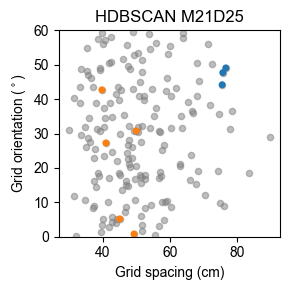

for module 0, there are 3 cells with average spacing 75.96795527689922
for module 1, there are 5 cells with average spacing 45.07035857093305
module 1 contains cells from ['ENTm5' 'VISl1' 'VISpl2/3']
module 0 contains cells from ['ENTm5' 'VISpl4']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 82)


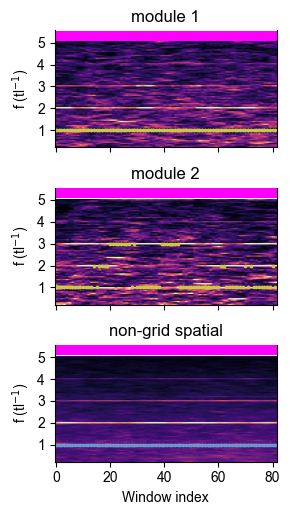

21 26
there are 162 non_grid and non_spatial_cells
there are 24 grid_cells
there are 148 non grid spatial cells
there are 14 non spatial cells
there are 5 speed cells
there are 191 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 12.930976914826656
Not merging labels 0 and 2 with distance 23.27718272401412
Not merging labels 1 and 2 with distance 10.469534808862202
Found 4 modules with HDBSCAN for mouse 21 day 26
for each module , the number of points is: [ 5  3  4 12]


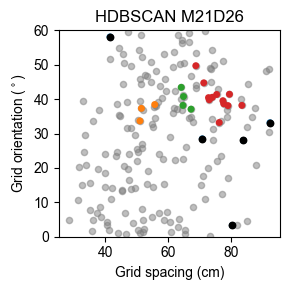

for module 0, there are 3 cells with average spacing 52.704988880266455
for module 1, there are 4 cells with average spacing 65.18358943535513
for module 2, there are 12 cells with average spacing 75.6350825836551
module 0 contains cells from ['ENTm5' 'ENTm6']
module 1 contains cells from ['ENTm3']
module 2 contains cells from ['ENTm2' 'ENTm3' 'ENTm5']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 88)


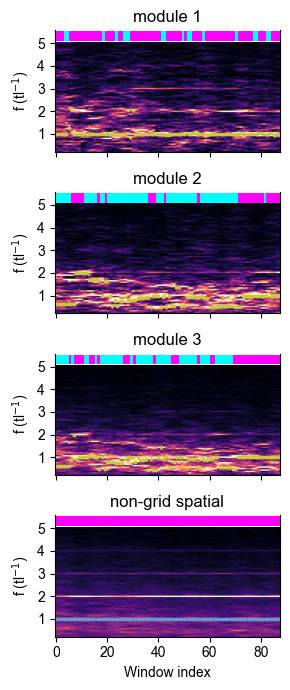

25 16
there are 32 non_grid and non_spatial_cells
there are 1 grid_cells
there are 28 non grid spatial cells
there are 4 non spatial cells
there are 5 speed cells
there are 38 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (77, 129)


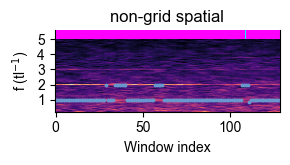

25 17
there are 57 non_grid and non_spatial_cells
there are 1 grid_cells
there are 20 non grid spatial cells
there are 37 non spatial cells
there are 10 speed cells
there are 68 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (77, 74)


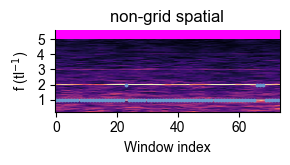

25 18
there are 84 non_grid and non_spatial_cells
there are 6 grid_cells
there are 55 non grid spatial cells
there are 29 non spatial cells
there are 56 speed cells
there are 146 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 25 day 18
for each module , the number of points is: [6]


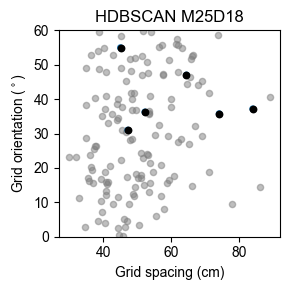

Identified 1 candidate modules
shape of S: (77, 46)


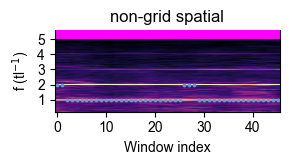

25 19
there are 37 non_grid and non_spatial_cells
there are 12 grid_cells
there are 34 non grid spatial cells
there are 3 non spatial cells
there are 10 speed cells
there are 59 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 14.506768751034713
Found 3 modules with HDBSCAN for mouse 25 day 19
for each module , the number of points is: [5 3 4]


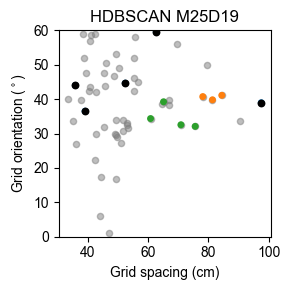

for module 0, there are 3 cells with average spacing 81.34142236534187
for module 1, there are 4 cells with average spacing 68.13287476384306
module 1 contains cells from ['ENTm1' 'ENTm2']
module 0 contains cells from ['ENTm2']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 84)


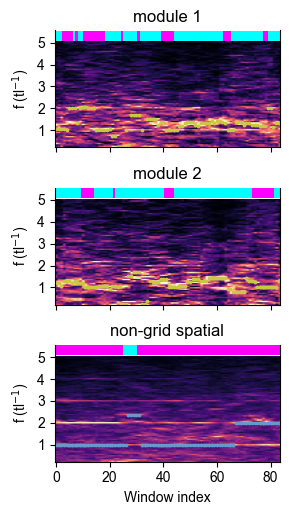

25 20
there are 42 non_grid and non_spatial_cells
there are 13 grid_cells
there are 38 non grid spatial cells
there are 4 non spatial cells
there are 12 speed cells
there are 67 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 15.741818751577284
Found 3 modules with HDBSCAN for mouse 25 day 20
for each module , the number of points is: [1 3 9]


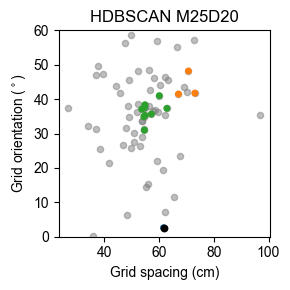

for module 0, there are 3 cells with average spacing 70.3536739667689
for module 1, there are 9 cells with average spacing 56.43120842495008
module 1 contains cells from ['ENTm1' 'ENTm2' 'PAR' 'VISpl5']
module 0 contains cells from ['ENTm1' 'ENTm2']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 168)


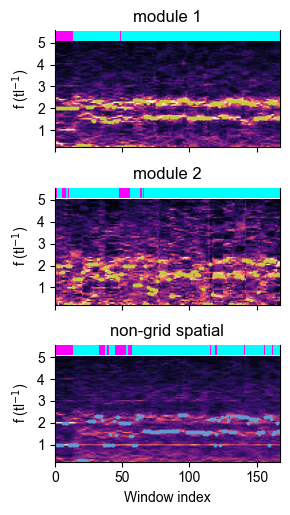

25 21
there are 24 non_grid and non_spatial_cells
there are 24 grid_cells
there are 18 non grid spatial cells
there are 6 non spatial cells
there are 16 speed cells
there are 64 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Merging labels 0 and 1 with distance 7.810719086275887
Found 2 modules with HDBSCAN for mouse 25 day 21
for each module , the number of points is: [ 4 20]


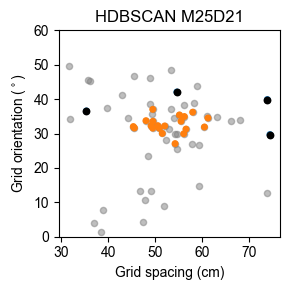

for module 0, there are 20 cells with average spacing 52.741411609123475
module 0 contains cells from ['ENTm1' 'ENTm2' 'PAR' 'VISpl5']
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 128)


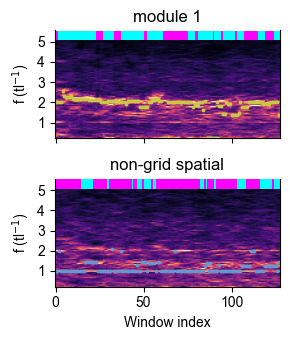

25 22
there are 129 non_grid and non_spatial_cells
there are 9 grid_cells
there are 85 non grid spatial cells
there are 44 non spatial cells
there are 51 speed cells
there are 189 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 21.150334950064664
Found 2 modules with HDBSCAN for mouse 25 day 22
for each module , the number of points is: [3 6]


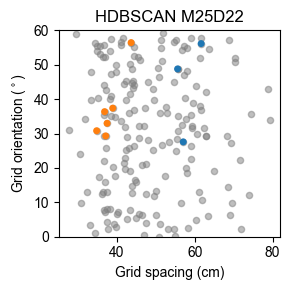

for module 0, there are 3 cells with average spacing 58.08447061582839
for module 1, there are 6 cells with average spacing 38.111269894827124
module 1 contains cells from ['ENTm1' 'VISp2/3' 'VISpl5']
module 0 contains cells from ['ENTm2' 'ENTm3']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 66)


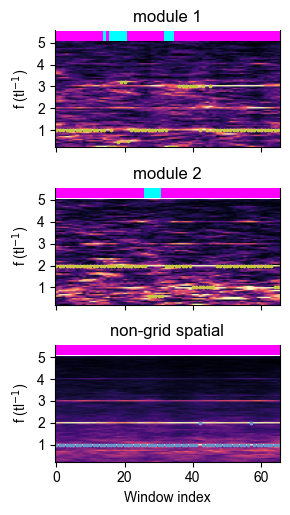

25 23
there are 193 non_grid and non_spatial_cells
there are 4 grid_cells
there are 113 non grid spatial cells
there are 80 non spatial cells
there are 30 speed cells
there are 227 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 25 day 23
for each module , the number of points is: [4]


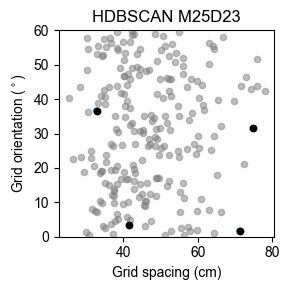

Identified 1 candidate modules
shape of S: (77, 94)


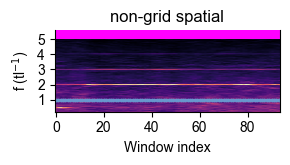

25 24
there are 44 non_grid and non_spatial_cells
there are 23 grid_cells
there are 40 non grid spatial cells
there are 4 non spatial cells
there are 2 speed cells
there are 69 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 26.979441530612775
Not merging labels 0 and 2 with distance 16.455743681011175
Not merging labels 1 and 2 with distance 10.686836455593717
Found 4 modules with HDBSCAN for mouse 25 day 24
for each module , the number of points is: [ 1  5  4 13]


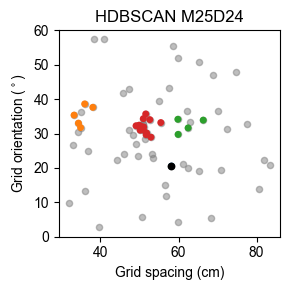

for module 0, there are 5 cells with average spacing 35.305404003465775
for module 1, there are 4 cells with average spacing 62.127313214275674
for module 2, there are 13 cells with average spacing 51.44469907502155
module 0 contains cells from ['VISpl5']
module 2 contains cells from ['ENTm2' 'VISpl5']
module 1 contains cells from ['ENTm1' 'ENTm2']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 105)


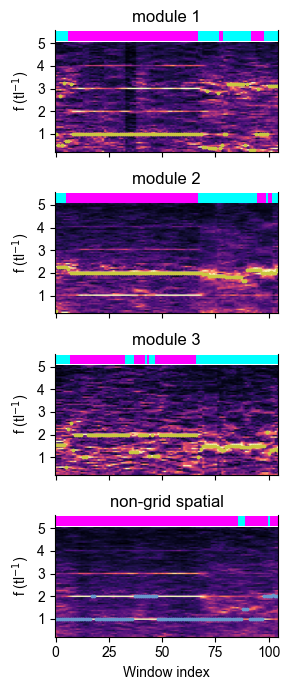

25 25
there are 92 non_grid and non_spatial_cells
there are 39 grid_cells
there are 78 non grid spatial cells
there are 14 non spatial cells
there are 21 speed cells
there are 152 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 22.544489655564348
Not merging labels 0 and 2 with distance 30.627480574951228
Not merging labels 1 and 2 with distance 14.22226483822343
Found 3 modules with HDBSCAN for mouse 25 day 25
for each module , the number of points is: [ 3  3 33]


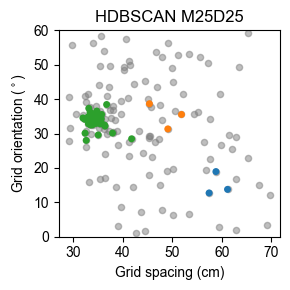

for module 0, there are 3 cells with average spacing 59.12650752692819
for module 1, there are 3 cells with average spacing 48.79472288460559
for module 2, there are 33 cells with average spacing 34.66376365589035
module 2 contains cells from ['VISp2/3' 'VISpl2/3' 'VISpl4' 'VISpl5']
module 1 contains cells from ['VISpl2/3' 'VISpl4' 'VISpl5']
module 0 contains cells from ['VISpl5']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 102)


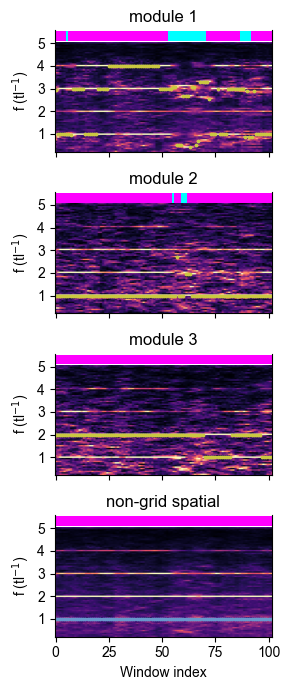

26 11
there are 133 non_grid and non_spatial_cells
there are 3 grid_cells
there are 122 non grid spatial cells
there are 11 non spatial cells
there are 28 speed cells
there are 164 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 26 day 11
for each module , the number of points is: [3]


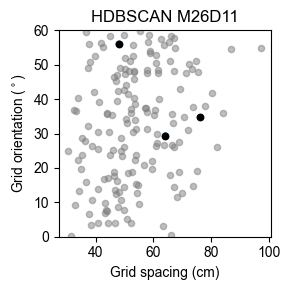

Identified 1 candidate modules
shape of S: (77, 105)


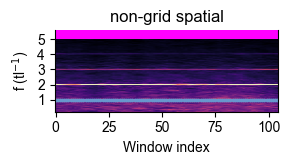

26 12
there are 101 non_grid and non_spatial_cells
there are 6 grid_cells
there are 90 non grid spatial cells
there are 11 non spatial cells
there are 46 speed cells
there are 153 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 26 day 12
for each module , the number of points is: [6]


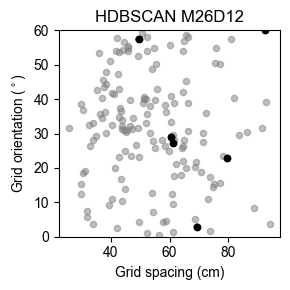

Identified 1 candidate modules
shape of S: (77, 125)


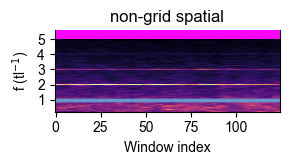

26 13
there are 85 non_grid and non_spatial_cells
there are 3 grid_cells
there are 84 non grid spatial cells
there are 1 non spatial cells
there are 9 speed cells
there are 97 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 26 day 13
for each module , the number of points is: [3]


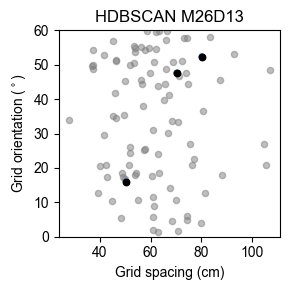

Identified 1 candidate modules
shape of S: (77, 134)


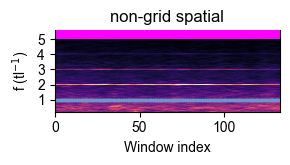

26 14
there are 5 non_grid and non_spatial_cells
there are 0 grid_cells
there are 3 non grid spatial cells
there are 2 non spatial cells
there are 5 speed cells
there are 10 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (77, 160)


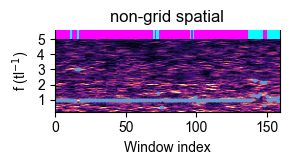

26 15
there are 104 non_grid and non_spatial_cells
there are 8 grid_cells
there are 90 non grid spatial cells
there are 14 non spatial cells
there are 29 speed cells
there are 141 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 21.255557307872653
Found 2 modules with HDBSCAN for mouse 26 day 15
for each module , the number of points is: [5 3]


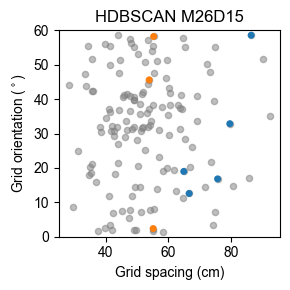

for module 0, there are 5 cells with average spacing 74.69566742897527
for module 1, there are 3 cells with average spacing 54.783212578229886
module 1 contains cells from ['ENTm3' 'ENTm5']
module 0 contains cells from ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 128)


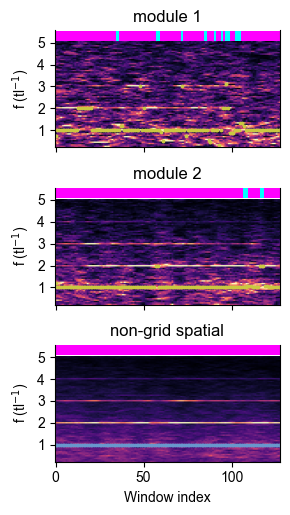

26 16
there are 44 non_grid and non_spatial_cells
there are 0 grid_cells
there are 38 non grid spatial cells
there are 6 non spatial cells
there are 4 speed cells
there are 48 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (77, 131)


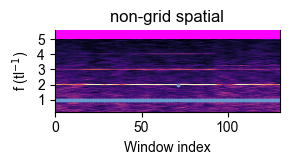

26 17
there are 21 non_grid and non_spatial_cells
there are 0 grid_cells
there are 12 non grid spatial cells
there are 9 non spatial cells
there are 4 speed cells
there are 25 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (77, 135)


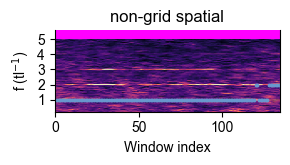

26 18
there are 72 non_grid and non_spatial_cells
there are 11 grid_cells
there are 68 non grid spatial cells
there are 4 non spatial cells
there are 11 speed cells
there are 94 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Merging labels 0 and 1 with distance 6.3163377436667885
Found 2 modules with HDBSCAN for mouse 26 day 18
for each module , the number of points is: [3 8]


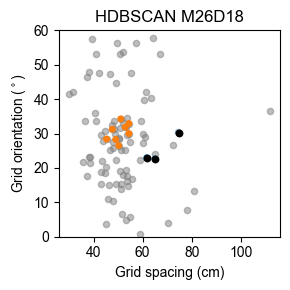

for module 0, there are 8 cells with average spacing 50.62149809144823
module 0 contains cells from ['ENTm1' 'ENTm2' 'ENTm3']
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 153)


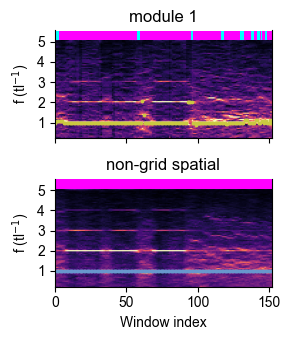

26 19
there are 274 non_grid and non_spatial_cells
there are 32 grid_cells
there are 263 non grid spatial cells
there are 11 non spatial cells
there are 36 speed cells
there are 342 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 28.057189411064744
Found 2 modules with HDBSCAN for mouse 26 day 19
for each module , the number of points is: [ 3 29]


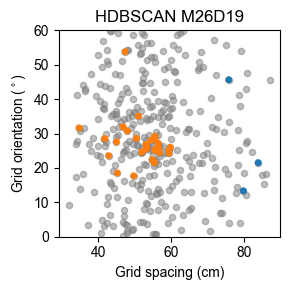

for module 0, there are 3 cells with average spacing 79.70418943974052
for module 1, there are 29 cells with average spacing 51.64994550698146
module 1 contains cells from ['ENTm2' 'ENTm3' 'PAR' 'VISpl5']
module 0 contains cells from ['ENTm2' 'ENTm3' 'VISpl5']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 159)


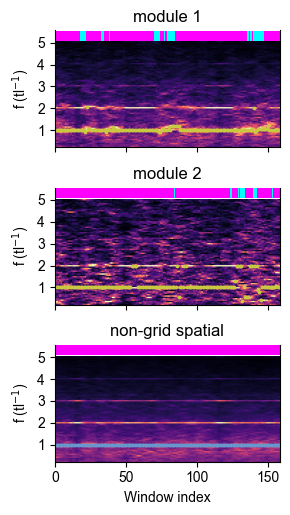

27 16
there are 14 non_grid and non_spatial_cells
there are 0 grid_cells
there are 5 non grid spatial cells
there are 9 non spatial cells
there are 5 speed cells
there are 19 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (77, 89)


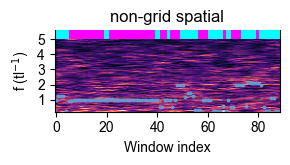

27 17
there are 24 non_grid and non_spatial_cells
there are 0 grid_cells
there are 24 non grid spatial cells
there are 0 non spatial cells
there are 1 speed cells
there are 25 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (77, 167)


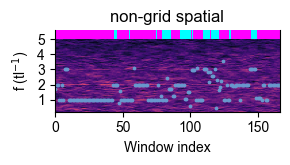

27 18
there are 62 non_grid and non_spatial_cells
there are 2 grid_cells
there are 59 non grid spatial cells
there are 3 non spatial cells
there are 11 speed cells
there are 75 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 27 day 18
for each module , the number of points is: [2]


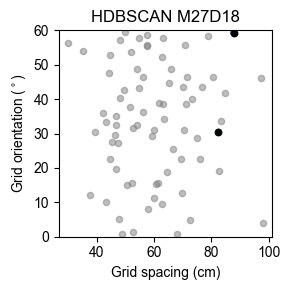

Identified 1 candidate modules
shape of S: (77, 198)


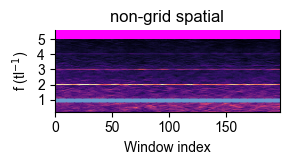

27 19
there are 73 non_grid and non_spatial_cells
there are 2 grid_cells
there are 68 non grid spatial cells
there are 5 non spatial cells
there are 8 speed cells
there are 83 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 27 day 19
for each module , the number of points is: [2]


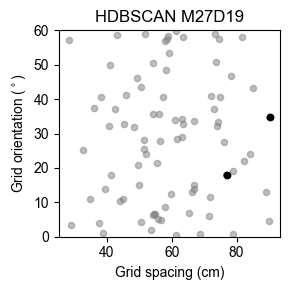

Identified 1 candidate modules
shape of S: (77, 171)


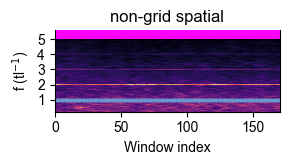

27 20
there are 22 non_grid and non_spatial_cells
there are 7 grid_cells
there are 20 non grid spatial cells
there are 2 non spatial cells
there are 1 speed cells
there are 30 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 27 day 20
for each module , the number of points is: [7]


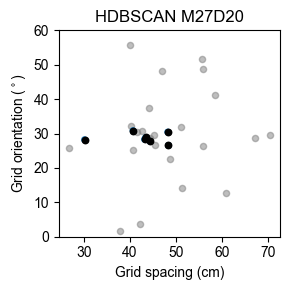

Identified 1 candidate modules
shape of S: (77, 179)


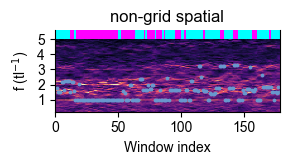

27 21
there are 31 non_grid and non_spatial_cells
there are 3 grid_cells
there are 18 non grid spatial cells
there are 13 non spatial cells
there are 22 speed cells
there are 56 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 27 day 21
for each module , the number of points is: [3]


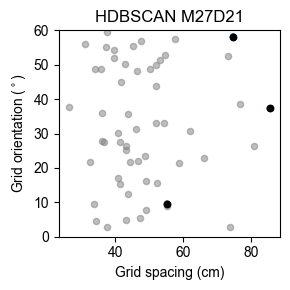

Identified 1 candidate modules
shape of S: (77, 154)


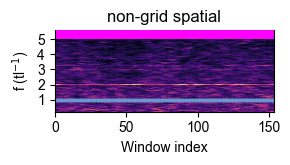

27 22
there are 50 non_grid and non_spatial_cells
there are 0 grid_cells
there are 32 non grid spatial cells
there are 18 non spatial cells
there are 15 speed cells
there are 65 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (77, 128)


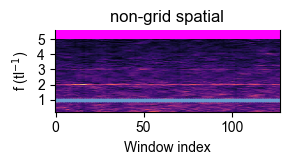

27 23
there are 96 non_grid and non_spatial_cells
there are 13 grid_cells
there are 94 non grid spatial cells
there are 2 non spatial cells
there are 3 speed cells
there are 112 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 28.10209207052715
Found 3 modules with HDBSCAN for mouse 27 day 23
for each module , the number of points is: [3 7 3]


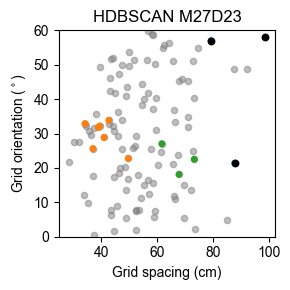

for module 0, there are 7 cells with average spacing 40.4384859057597
for module 1, there are 3 cells with average spacing 67.61459751757187
module 0 contains cells from ['ENTm2' 'ENTm3' 'VISpl6a']
module 1 contains cells from ['ENTm3']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 191)


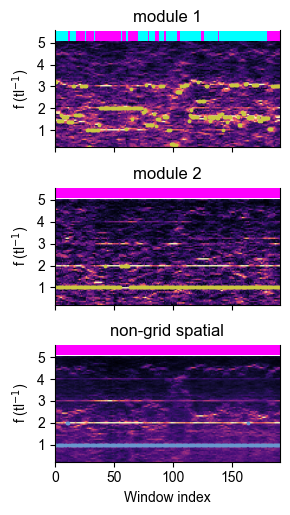

27 24
there are 178 non_grid and non_spatial_cells
there are 6 grid_cells
there are 173 non grid spatial cells
there are 5 non spatial cells
there are 5 speed cells
there are 189 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 27 day 24
for each module , the number of points is: [6]


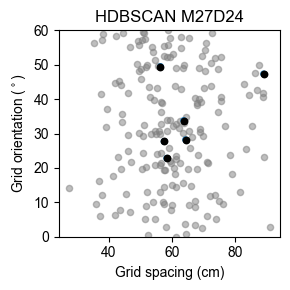

Identified 1 candidate modules
shape of S: (77, 176)


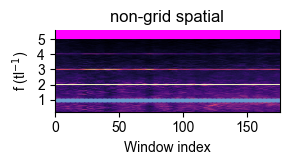

27 26
there are 22 non_grid and non_spatial_cells
there are 12 grid_cells
there are 20 non grid spatial cells
there are 2 non spatial cells
there are 1 speed cells
there are 35 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Merging labels 0 and 1 with distance 3.3380266777636933
Merging labels 0 and 2 with distance 6.572598214624529
Merging labels 1 and 2 with distance 3.2424951431076967
Found 2 modules with HDBSCAN for mouse 27 day 26
for each module , the number of points is: [ 1 11]


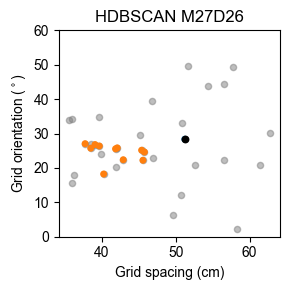

for module 0, there are 11 cells with average spacing 41.72919672948084
module 0 contains cells from ['PAR' 'VISpl5' 'VISpl6a']
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 174)


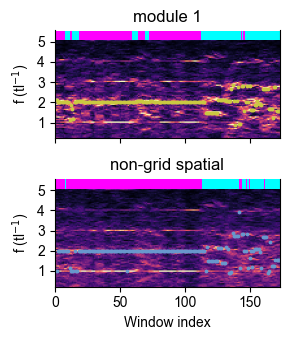

28 16
there are 51 non_grid and non_spatial_cells
there are 4 grid_cells
there are 48 non grid spatial cells
there are 3 non spatial cells
there are 46 speed cells
there are 101 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 28 day 16
for each module , the number of points is: [4]


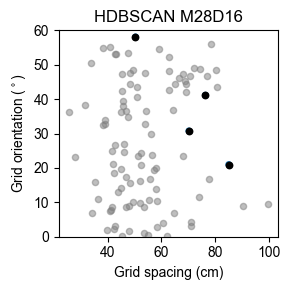

Identified 1 candidate modules
shape of S: (77, 60)


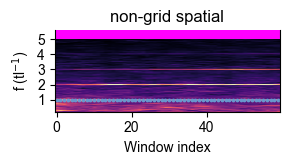

28 17
there are 75 non_grid and non_spatial_cells
there are 4 grid_cells
there are 70 non grid spatial cells
there are 5 non spatial cells
there are 20 speed cells
there are 99 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 28 day 17
for each module , the number of points is: [4]


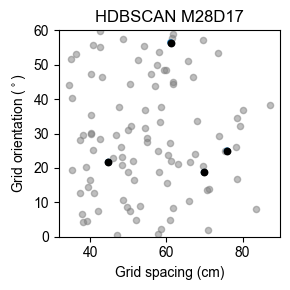

Identified 1 candidate modules
shape of S: (77, 59)


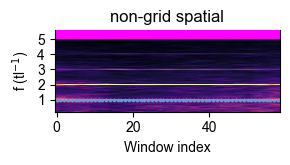

28 18
there are 107 non_grid and non_spatial_cells
there are 0 grid_cells
there are 81 non grid spatial cells
there are 26 non spatial cells
there are 44 speed cells
there are 151 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (77, 70)


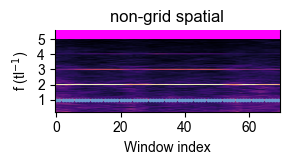

28 19
there are 86 non_grid and non_spatial_cells
there are 18 grid_cells
there are 83 non grid spatial cells
there are 3 non spatial cells
there are 16 speed cells
there are 120 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 16.918558750560678
Found 2 modules with HDBSCAN for mouse 28 day 19
for each module , the number of points is: [ 4 14]


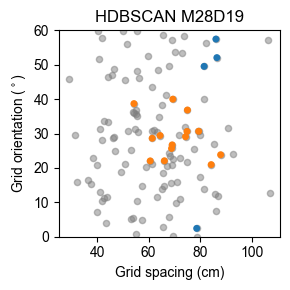

for module 0, there are 4 cells with average spacing 83.21904826097995
for module 1, there are 14 cells with average spacing 70.7447402656941
module 1 contains cells from ['ENTm2' 'ENTm3' 'ENTm5']
module 0 contains cells from ['ENTm3' 'ENTm5']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 69)


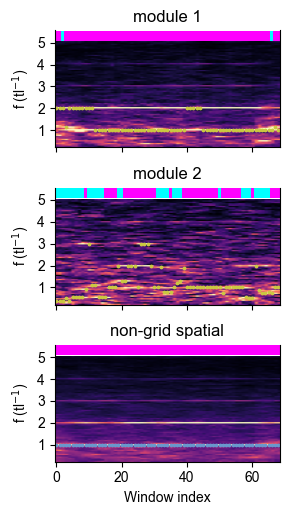

28 20
there are 166 non_grid and non_spatial_cells
there are 3 grid_cells
there are 144 non grid spatial cells
there are 22 non spatial cells
there are 45 speed cells
there are 214 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 28 day 20
for each module , the number of points is: [3]


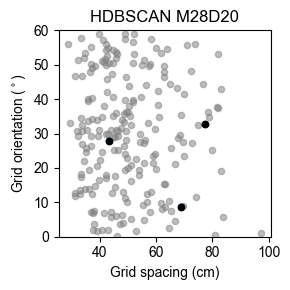

Identified 1 candidate modules
shape of S: (77, 78)


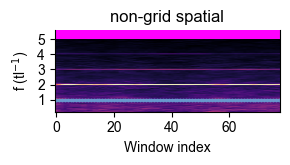

28 21
there are 15 non_grid and non_spatial_cells
there are 2 grid_cells
there are 13 non grid spatial cells
there are 2 non spatial cells
there are 4 speed cells
there are 21 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 28 day 21
for each module , the number of points is: [2]


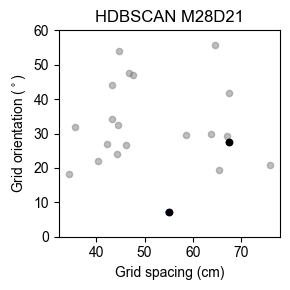

Identified 1 candidate modules
shape of S: (77, 75)


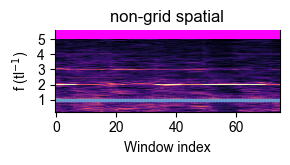

28 22
there are 17 non_grid and non_spatial_cells
there are 0 grid_cells
there are 12 non grid spatial cells
there are 5 non spatial cells
there are 6 speed cells
there are 23 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (77, 95)


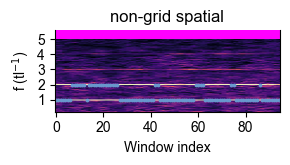

28 23
there are 108 non_grid and non_spatial_cells
there are 7 grid_cells
there are 92 non grid spatial cells
there are 16 non spatial cells
there are 25 speed cells
there are 140 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 19.296199239480284
Found 2 modules with HDBSCAN for mouse 28 day 23
for each module , the number of points is: [4 3]


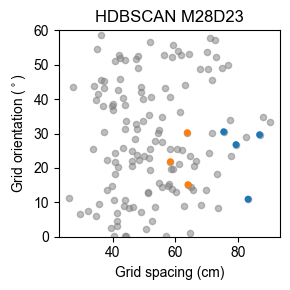

for module 0, there are 4 cells with average spacing 81.31580442277227
for module 1, there are 3 cells with average spacing 62.13052074128293
module 1 contains cells from ['ENTm3']
module 0 contains cells from ['ENTm2' 'ENTm3']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 87)


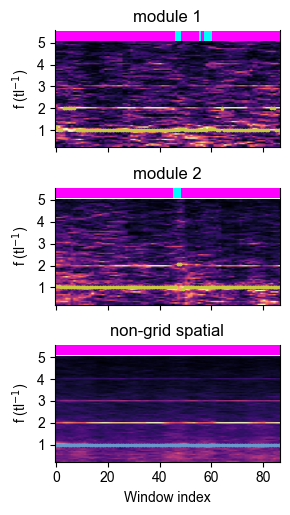

28 25
there are 104 non_grid and non_spatial_cells
there are 24 grid_cells
there are 100 non grid spatial cells
there are 4 non spatial cells
there are 7 speed cells
there are 135 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 11.92490731394178
Found 3 modules with HDBSCAN for mouse 28 day 25
for each module , the number of points is: [ 2  4 18]


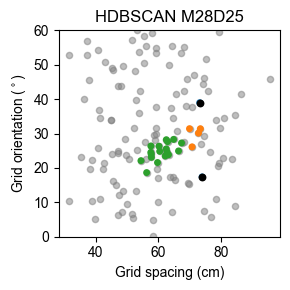

for module 0, there are 4 cells with average spacing 71.75766065742434
for module 1, there are 18 cells with average spacing 60.94923689327594
module 1 contains cells from ['ENTm3' 'ENTm5']
module 0 contains cells from ['ENTm3' 'ENTm5']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 100)


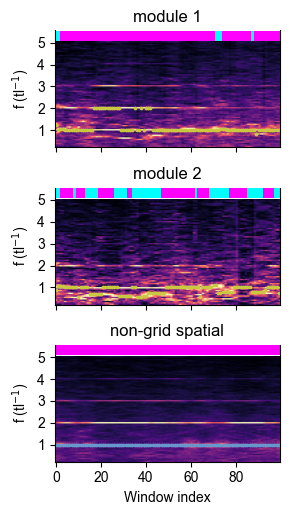

29 16
there are 38 non_grid and non_spatial_cells
there are 4 grid_cells
there are 35 non grid spatial cells
there are 3 non spatial cells
there are 14 speed cells
there are 56 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 29 day 16
for each module , the number of points is: [4]


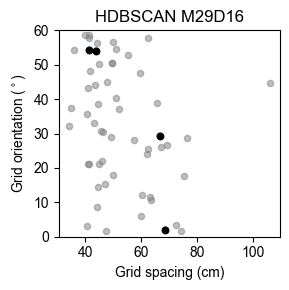

Identified 1 candidate modules
shape of S: (77, 89)


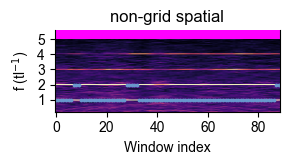

29 17
there are 115 non_grid and non_spatial_cells
there are 5 grid_cells
there are 75 non grid spatial cells
there are 40 non spatial cells
there are 32 speed cells
there are 152 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 29 day 17
for each module , the number of points is: [5]


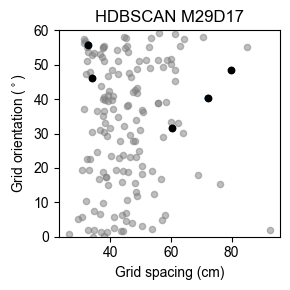

Identified 1 candidate modules
shape of S: (77, 85)


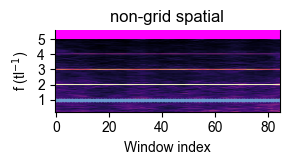

29 18
there are 132 non_grid and non_spatial_cells
there are 1 grid_cells
there are 60 non grid spatial cells
there are 72 non spatial cells
there are 32 speed cells
there are 165 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (77, 81)


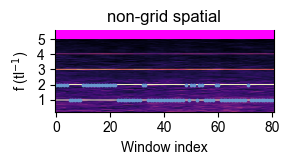

29 19
there are 104 non_grid and non_spatial_cells
there are 11 grid_cells
there are 82 non grid spatial cells
there are 22 non spatial cells
there are 21 speed cells
there are 136 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Merging labels 0 and 1 with distance 1.8106178550302843
Found 2 modules with HDBSCAN for mouse 29 day 19
for each module , the number of points is: [5 6]


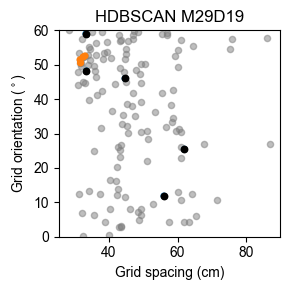

for module 0, there are 6 cells with average spacing 32.2183078438621
module 0 contains cells from ['ENTm2' 'ENTm3']
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 84)


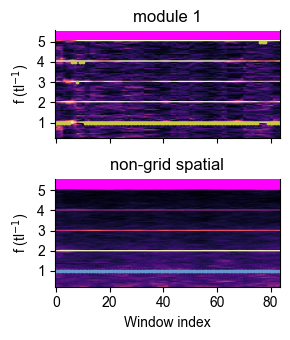

29 20
there are 190 non_grid and non_spatial_cells
there are 12 grid_cells
there are 165 non grid spatial cells
there are 25 non spatial cells
there are 40 speed cells
there are 242 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 11.092632894751768
Found 3 modules with HDBSCAN for mouse 29 day 20
for each module , the number of points is: [3 4 5]


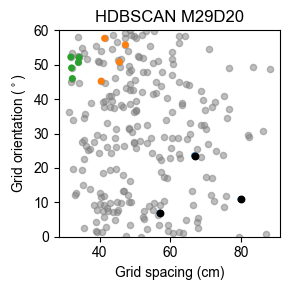

for module 0, there are 4 cells with average spacing 43.617075089636685
for module 1, there are 5 cells with average spacing 32.77808171564158
module 1 contains cells from ['ENTm3' 'ENTm5']
module 0 contains cells from ['ENTm2']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 78)


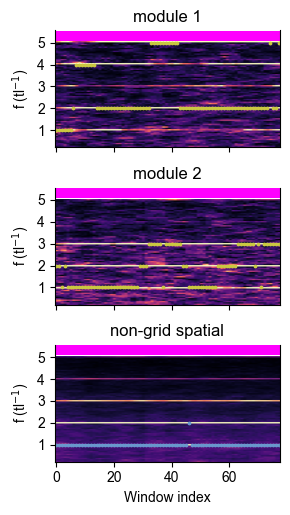

29 21
there are 127 non_grid and non_spatial_cells
there are 3 grid_cells
there are 80 non grid spatial cells
there are 47 non spatial cells
there are 24 speed cells
there are 154 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 1 modules with HDBSCAN for mouse 29 day 21
for each module , the number of points is: [3]


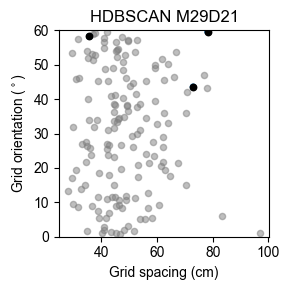

Identified 1 candidate modules
shape of S: (77, 94)


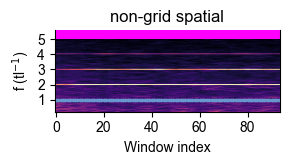

29 22
there are 61 non_grid and non_spatial_cells
there are 0 grid_cells
there are 43 non grid spatial cells
there are 18 non spatial cells
there are 19 speed cells
there are 80 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Identified 1 candidate modules
shape of S: (77, 84)


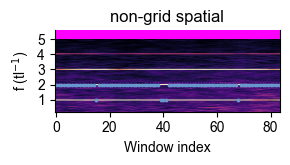

29 23
there are 156 non_grid and non_spatial_cells
there are 24 grid_cells
there are 147 non grid spatial cells
there are 9 non spatial cells
there are 29 speed cells
there are 209 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Merging labels 0 and 1 with distance 6.480460847707891
Found 2 modules with HDBSCAN for mouse 29 day 23
for each module , the number of points is: [ 3 21]


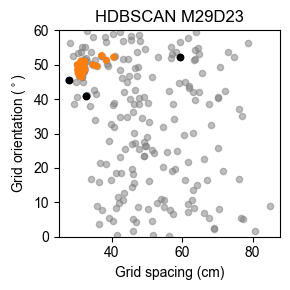

for module 0, there are 21 cells with average spacing 32.709071671458304
module 0 contains cells from ['ENTm2' 'ENTm3' 'ENTm5' 'PAR']
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 66)


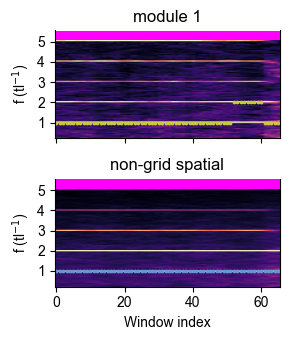

29 25
there are 191 non_grid and non_spatial_cells
there are 14 grid_cells
there are 149 non grid spatial cells
there are 42 non spatial cells
there are 65 speed cells
there are 270 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Merging labels 0 and 1 with distance 3.6829643822366522
Found 2 modules with HDBSCAN for mouse 29 day 25
for each module , the number of points is: [ 2 12]


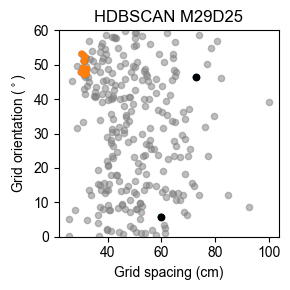

for module 0, there are 12 cells with average spacing 31.218082139007283
module 0 contains cells from ['ENTm2' 'ENTm3' 'ENTm5']
Identified 1 candidate modules
Identified 1 candidate modules
shape of S: (77, 84)


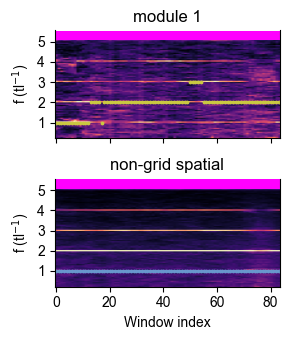

In [6]:
mouse_days = {20: [14,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }

for mouse, days in mouse_days.items():
    for day in days:
        tcs, tcs_time, _, _, _, _ = compute_vr_tcs(mouse, day)

        gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95)
        # Grid cells
        g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                        figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True)
        
        fig, ax = plt.subplots(
            nrows=len(g_m_cluster_ids)+1,
            ncols=1,
            figsize=(3, (len(g_m_cluster_ids)+1)*1.75),
            squeeze=False,
            sharex='col'
        )
        
        for m, cluster_ids in enumerate(g_m_cluster_ids):
            tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
            results = spectral_analysis(tcs_to_use, tl, bs=bs)
            spectrograms = results[3] 
            S = spectrograms.mean(0)
            # Spectrogram
            ax[m,0].set_title(f'module {m+1}')
            ax[m,0].imshow(S, origin='lower', aspect='auto', vmax=0.25, cmap='magma')
            max_peaks = np.argmax(S, axis=0)
            ax[m,0].scatter(np.arange(S.shape[1]), max_peaks, color='#CAC841',s=3)
            ax[m,0].set_yticks(peak_indices, [1, 2, 3, 4, 5])
            ax[m,0].set_ylabel(r'f (tl$^{-1}$)')
            ax[m,0].spines['top'].set_visible(False)
            
            # Cluster labels: 1 if max at peak_indices_gm, else 0
            labels = np.isin(max_peaks, peak_indices).astype(int)
            ax[m,0].scatter(
                np.arange(S.shape[1]),
                np.full(S.shape[1], 81),  # y just above the top
                c=labels,
                cmap='cool',
                marker='s',
                s=50,
                edgecolor='none',
                clip_on=True,
                vmin=0, vmax=1,
            )

        # Non-grid spatial cells
        tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs}
        results = spectral_analysis(tcs_to_use, tl, bs=bs)
        spectrograms = results[3] 
        S = spectrograms.mean(0)

        print(f'shape of S: {S.shape}')
        # spectrogram
        ax[-1,0].set_title(f'non-grid spatial')
        ax[-1,0].imshow(S, origin='lower', aspect='auto', vmax=0.25, cmap='magma')
        max_peaks = np.argmax(S, axis=0)
        ax[-1,0].scatter(np.arange(S.shape[1]), max_peaks, color='#6897CD',s=3)
        ax[-1,0].set_yticks(peak_indices, [1, 2, 3, 4, 5])
        ax[-1,0].set_ylabel(r'f (tl$^{-1}$)')
        ax[-1,0].set_xlabel('Window index')
        ax[-1,0].spines['top'].set_visible(False)
        labels = np.isin(max_peaks, peak_indices).astype(int)
        ax[-1,0].scatter(
            np.arange(S.shape[1]),
            np.full(S.shape[1], 81),  # y just above the top
            c=labels,
            cmap='cool',
            marker='s',
            s=50,
            edgecolor='none',
            clip_on=True,
            vmin=0, vmax=1,
        )
        plt.tight_layout()
        plt.show()
